# Bandit パラメータ sweep: Q 学習の学習曲線

2 本腕バンディット上の Q 学習について、学習率 α と逆温度 β を振り、
学習曲線（最適腕を選んだ割合）がどう変わるかを比較する。

| セクション | 内容 |
|---|---|
| 1 | セットアップ |
| 2 | 実行パラメータ設定 |
| 3 | run.jl 実行 |
| 4 | 結果読み込み・集計 |
| 5 | 学習曲線の比較 |
| 6 | 最終性能サマリ |

## 1. セットアップ

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io=devnull)
Pkg.instantiate(; io=devnull)
using DrWatson, CSV, DataFrames, Plots, Statistics, Printf

# moving_average などのシミュレーション関数
include(srcdir("bandit.jl"))

moving_average

## 2. 実行パラメータ設定

学習率 α と逆温度 β の組み合わせを sweep する。

In [2]:
paramsets = [
    Dict(
        :seed     => 42,
        :n_trials => 100,
        :n_reps   => 200,
        :alpha    => a,
        :beta     => b,
    )
    for a in [0.1, 0.3, 0.6]
    for b in [2.0, 5.0]
]

println("Total: $(length(paramsets))")
paramsets

Total: 6


6-element Vector{Dict{Symbol, Real}}:
 Dict(:n_trials => 100, :alpha => 0.1, :beta => 2.0, :n_reps => 200, :seed => 42)
 Dict(:n_trials => 100, :alpha => 0.1, :beta => 5.0, :n_reps => 200, :seed => 42)
 Dict(:n_trials => 100, :alpha => 0.3, :beta => 2.0, :n_reps => 200, :seed => 42)
 Dict(:n_trials => 100, :alpha => 0.3, :beta => 5.0, :n_reps => 200, :seed => 42)
 Dict(:n_trials => 100, :alpha => 0.6, :beta => 2.0, :n_reps => 200, :seed => 42)
 Dict(:n_trials => 100, :alpha => 0.6, :beta => 5.0, :n_reps => 200, :seed => 42)

## 3. run.jl 実行

各パラメータ条件について `scripts/run.jl` をサブプロセスで実行し、
結果を `datadir("sims")` に CSV 保存する。

In [ ]:
run_script = projectdir("scripts", "run.jl")

for p in paramsets
    jl  = joinpath(Sys.BINDIR, "julia")
    cmd = `$jl $run_script $(p[:seed]) $(p[:n_trials]) $(p[:n_reps]) $(p[:alpha]) $(p[:beta])`
    println("Running: ", cmd)
    run(cmd)
end

## 4. 結果読み込み・集計

保存した CSV を `savename` で特定して読み込み、1 つの DataFrame にまとめる。

In [4]:
sim_dir = datadir("sims")

rows = DataFrame[]
for p in paramsets
    params = Dict(
        "alpha"    => p[:alpha],
        "beta"     => p[:beta],
        "seed"     => p[:seed],
        "n_trials" => p[:n_trials],
        "n_reps"   => p[:n_reps],
    )
    f = joinpath(sim_dir, savename("bandit", params, "csv"))
    isfile(f) || (println("Missing: ", f); continue)
    push!(rows, CSV.read(f, DataFrame))
end

isempty(rows) && error("No result files were loaded.")
df = vcat(rows...)
println("Rows: $(nrow(df))")
first(df, 5)

Rows: 600


Row,trial,p_optimal,alpha,beta,seed,n_trials,n_reps
,Int64,Float64,Float64,Float64,Int64,Int64,Int64
1,1,0.485,0.1,2.0,42,100,200
2,2,0.495,0.1,2.0,42,100,200
3,3,0.53,0.1,2.0,42,100,200
4,4,0.535,0.1,2.0,42,100,200
5,5,0.57,0.1,2.0,42,100,200


In [5]:
agg = combine(
    groupby(df, [:alpha, :beta]),
    :p_optimal => last => :final_p_optimal,
    :p_optimal => mean => :mean_p_optimal,
)
sort!(agg, [:alpha, :beta])
agg

Row,alpha,beta,final_p_optimal,mean_p_optimal
,Float64,Float64,Float64,Float64
1,0.1,2.0,0.75,0.73395
2,0.1,5.0,0.96,0.9179
3,0.3,2.0,0.735,0.75045
4,0.3,5.0,0.93,0.9271
5,0.6,2.0,0.715,0.74735
6,0.6,5.0,0.875,0.8983


## 5. 学習曲線の比較

パラメータ条件ごとに、最適腕を選んだ割合の推移を重ねて描画する。

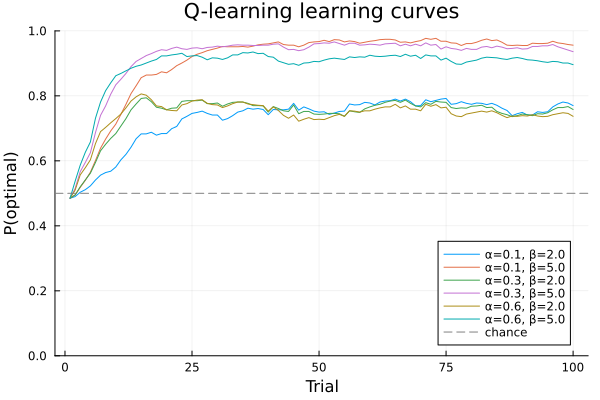

In [6]:
window = 5
plt = plot(;
    xlabel = "Trial",
    ylabel = "P(optimal)",
    title  = "Q-learning learning curves",
    ylim   = (0, 1),
    legend = :bottomright,
    lw     = 2,
)

for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    smoothed = moving_average(sub.p_optimal, window)
    plot!(plt, sub.trial, smoothed; label = "\u03b1=$(p[:alpha]), \u03b2=$(p[:beta])")
end

hline!(plt, [0.5]; linestyle=:dash, color=:gray, label="chance")
savefig(plt, plotsdir("learning_curves_sweep.png"))
plt

## 6. 最終性能サマリ

In [7]:
println("=== 最終性能（最後の試行の P(optimal)）===\n")
for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    @printf("  \u03b1=%.1f  \u03b2=%.1f  final=%.3f  mean=%.3f\n",
        p[:alpha], p[:beta], sub.p_optimal[end], mean(sub.p_optimal))
end

=== 最終性能（最後の試行の P(optimal)）===

  α=0.1  β=2.0  final=0.750  mean=0.734
  α=0.1  β=5.0  final=0.960  mean=0.918
  α=0.3  β=2.0  final=0.735  mean=0.750
  α=0.3  β=5.0  final=0.930  mean=0.927
  α=0.6  β=2.0  final=0.715  mean=0.747
  α=0.6  β=5.0  final=0.875  mean=0.898
